# Validation Pipeline Sketch V1

## 0. Imports and Set-Up:

In [35]:
from typing import Tuple, Type, Dict, List

import scanpy as sc
import numpy as np
import pandas as pd

from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, jaccard_score, f1_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

from sklearn.model_selection import train_test_split

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [13]:
adata = sc.datasets.ebi_expression_atlas(accession='E-GEOD-98816', filter_boring=True)
adata_vis = sc.datasets.ebi_expression_atlas(accession='E-GEOD-98816', filter_boring=True)
adata.obs.head()

,Sample Characteristic[genotype]
SRR5529430,Cldn5-GFP
SRR5529431,Cldn5-GFP
SRR5529432,Cldn5-GFP
SRR5529433,Cldn5-GFP
SRR5529434,Cldn5-GFP


/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


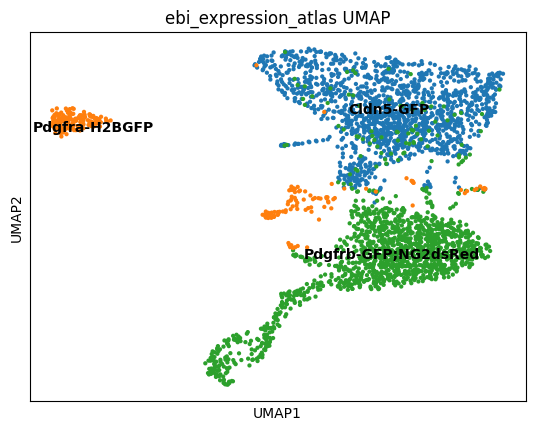

In [14]:
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)
sc.pp.highly_variable_genes(adata_vis, n_top_genes=1000, subset=True)
sc.pp.scale(adata_vis)
sc.tl.pca(adata_vis, svd_solver='arpack')

sc.pp.neighbors(adata_vis, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_vis)

sc.pl.umap(
    adata_vis, color='Sample Characteristic[genotype]',
    title='ebi_expression_atlas UMAP',
    legend_loc='on data',
    show=True
)

In [15]:
df_expr = adata.to_df()
df_expr['cell_type'] = adata.obs['Sample Characteristic[genotype]'].values

In [16]:
df_expr.shape

(3186, 28258)

In [17]:
df_expr['cell_type'].value_counts()

cell_type
Pdgfrb-GFP;NG2dsRed    1484
Cldn5-GFP              1445
Pdgfra-H2BGFP           257
Name: count, dtype: int64

In [18]:
df_expr.describe().T

,count,mean,std,min,25%,50%,75%,max
ENSMUSG00000000001,3186.0,66.615822,143.379898,0.0,0.000000,0.000000,50.75000,1650.000000
ENSMUSG00000000003,3186.0,0.003139,0.114791,0.0,0.000000,0.000000,0.00000,5.000000
ENSMUSG00000000028,3186.0,94.060928,72.213524,0.0,46.633774,79.758419,126.08358,955.594238
ENSMUSG00000000037,3186.0,0.316698,7.246142,0.0,0.000000,0.000000,0.00000,280.000000
ENSMUSG00000000049,3186.0,0.081921,2.647093,0.0,0.000000,0.000000,0.00000,128.000000
...,...,...,...,...,...,...,...,...
ENSMUSG00000118670,3186.0,0.034212,1.038546,0.0,0.000000,0.000000,0.00000,49.000000
ENSMUSG00000118671,3186.0,0.246740,5.108175,0.0,0.000000,0.000000,0.00000,272.132751
ENSMUSG00000118672,3186.0,0.147739,4.639779,0.0,0.000000,0.000000,0.00000,225.000000
ENSMUSG00001074846,3186.0,0.013348,0.383687,0.0,0.000000,0.000000,0.00000,17.000000


In [21]:
X = df_expr.values
n_samples = X.shape[0]

---
## 1. Helper Functions:

In [23]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> Tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :n_samples: total number of samples in data frame.
    :ratio: ratio for subsampling, between 0 and 1. 
    :random_state: random seed for rng.
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arrange(n_samples)
    train_size = int(np.float(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [ ]:
def cluster_and_get_labels(X_train: np.ndarray, algorithm: Type[ClusterMixin], **cluster_kwargs) -> Tuple[np.ndarray, ClusterMixin]:
    """
    fits `algorithm` on X_train, returns an array of cluster labels, length = len(X_train).

    :X_train: numpy array of shape (n_train, n_features)
    :algorithm: a clustering class or function (e.g., sklearn.cluster.KMeans)
    :cluster_kwargs: parameters passed to the clustering constructor, e.g. n_clusters=k, random_state, etc.

    :return:
        labels: 1D array of length n_train, cluster assignments (0..k-1)
        fitted_model: the trained clustering object
    """
    model = algorithm(**cluster_kwargs)
    labels = model.fit_predict(X_train)
    
    return labels, model

In [29]:
def train_rf(X_train: np.ndarray, labels_train: np.ndarray, **rf_kwargs) -> RandomForestClassifier:
    """
    trains a random forest classifier to predict cluster labels from features.
    returns the fitted RandomForestClassifier.
    
    :X_train: numpy array, shape = (n_train, n_features)
    :labels_train: 1D array of ints (cluster ids)
    :rf_kwargs: keyword args for RandomForestClassifier, e.g. n_estimators, max_depth, random_state
    
    :return:
        rf_model: fitted RandomForestClassifier
    """
    rf_model = RandomForestClassifier(**rf_kwargs)
    rf_model.fit(X_train, labels_train)
    
    return rf_model

In [33]:
def compute_global_metrics(labels_A: np.ndarray, labels_B: np.ndarray) -> Dict[str, float]:
    """
    compute ARI and NMI between two label vectors of equal length.
    
    :labels_A: 1d array of ints (cluster ids) for first partition
    :labels_B: 1d array of ints (cluster ids) for second partition
    
    :return: a dict {"ARI": ari_value, "NMI": nmi_value}
    """
    ari = adjusted_rand_score(labels_A, labels_B)
    nmi = normalized_mutual_info_score(labels_A, labels_B)
    
    return {"ARI": ari, "NMI": nmi}

In [ ]:
def align_cluster_labels_and_compute_scores(true_labels: np.ndarray, pred_labels: np.ndarray, score_type: str = 'jaccard') -> Tuple[List[float], float, float]:
    """
    aligns predicted labels to true labels using Hungarian algorithm, then computes a score (jaccard or f1) for each aligned cluster.
    
    :true_labels: 1D array of ints (ground-truth or reference cluster IDs)
    :pred_labels: 1D array of ints (predicted cluster IDs)
    :score_type: "jaccard" or "f1"
    
    returns:
        per_cluster_scores: list of length = n_clusters, where each element is the jaccard or f1 for that aligned cluster pair.
        median_score: median of per_cluster_scores
        iqr_score: interquartile range of per_cluster_scores
    """
    cm = confusion_matrix(true_labels, pred_labels)  # get confusion matrix, rows: true clusters, cols: predicted clusters
    row_idx, col_idx = linear_sum_assignment(-cm)  # maximize total matches (use -cm as cost)
    alignment = dict(zip(col_idx, row_idx))  # cleate mapping from pred_cluster to "aligned true cluster" via col_idx to row_idx
    
    per_scores = []
    for p_cluster, t_cluster in alignment.items():  # for each aligned cluster pair, compute jaccard or f1
        mask_true = (true_labels == t_cluster)  # get boolean masks
        mask_pred = (pred_labels == p_cluster)
        
        if score_type == 'jaccard':
            score = jaccard_score(mask_true.astype(int), mask_pred.astype(int))
        elif score_type == 'f1':
            score = f1_score(mask_true.astype(int), mask_pred.astype(int))
        else:
            raise ValueError("score_type must be 'jaccard' or 'f1'")
    
        per_scores.append(score)
        
    per_scores = np.array(per_scores)
    median_score = np.median(per_scores)
    iqr_score = np.percentile(per_scores, 75) - np.percentile(per_scores, 25)
    return per_scores, median_score, iqr_score